# TOBS Transformer Flux Maximisation
**Reference:** Sivapuram & Picelli (2018) — *Topology optimization of binary structures using ILP*, FEAD 139, 49–61.

| Section | Mesh | Init | Purpose |
|---------|------|------|---------|
| A | coarse maxh=0.5 | void | baseline |
| B | fine maxh=0.05 | void | reference optimum |
| C | coarse maxh=0.5 | projected from B | geometric warm-start |
| E | coarse maxh=0.5 | void | BiGRU-corrected sensitivity |


## Shared setup

In [1]:
from numpy import pi
import numpy as np
import matplotlib.pyplot as plt
from ngsolve import (CF, grad, H1, L2, BilinearForm, LinearForm,
                     GridFunction, Integrate, dx, VOL)
from ngsolve.webgui import Draw
from scipy.optimize import linprog
from scipy.sparse  import hstack, vstack, eye, csr_matrix
from scipy.spatial import KDTree
from geometry     import transformer
from solver       import solve, flux, curl
from optimization import solve_adjoint

mu0      = 4e-7 * pi
mur      = 1000
j        = 1e6
dnu_drho = CF(1/(mu0*mur) - 1/mu0)
V_TARGET = 0.30

def nu(rho, p=1):
    return 1/mu0 + rho**p * (1/(mu0*mur) - 1/mu0)

def state(rho, mesh):
    fes = H1(mesh, order=1, dirichlet='dOmega')
    a, v = fes.TnT()
    bf = BilinearForm(curl(v) * (nu(rho) * curl(a)) * dx)
    lf = LinearForm(j * v * dx('Pp') - j * v * dx('Pm'))
    return solve(bf, lf)

# ── sensitivity helpers — kept exactly as original ────────────────────────
def f(sol):
    return -flux(sol)

def df(a, rho, aStar):
    return aStar*dx('Sm') - aStar*dx('Sp')

def f_prime(state_gf, adjoint_gf, rho):
    fes   = rho.space
    drho  = fes.TestFunction()
    lform = LinearForm(fes)
    lform += curl(adjoint_gf) * (dnu_drho * curl(state_gf)) * drho * dx
    lform.Assemble()
    return lform

def f_derivative(a_rho, rho, Kinv):
    p_rho   = solve_adjoint(a_rho, rho, Kinv, df)
    grad_gf = GridFunction(rho.space)
    grad_gf.vec.data = f_prime(a_rho, p_rho, rho).vec
    return grad_gf

def compute_sensitivity(rho, mesh):
    u, Kinv  = state(rho, mesh)
    obj_val  = f(u)
    sens_gf  = f_derivative(u, rho, Kinv)
    sens_vec = sens_gf.vec.FV().NumPy()[:].copy()
    return obj_val, sens_vec, u

# ─────────────────────────────────────────────────────────────────────────────
def element_flux_density(u_gf, mesh):
    B_sq = Integrate(grad(u_gf)*grad(u_gf), mesh, element_wise=True).NumPy()[:]
    area = Integrate(1, mesh, element_wise=True).NumPy()[:]
    return np.sqrt(np.where(area > 1e-30, B_sq/area, 0.0))

def tobs_update(x, s, eVol, V, delta):
    N = len(x); I = eye(N, format='csr')
    eV = csr_matrix(eVol.reshape(1, N))
    A = vstack([hstack([eV,                  csr_matrix((1, N))]),
                hstack([csr_matrix((1, N)),  csr_matrix(np.ones((1, N)))]),
                hstack([ I, -I]),
                hstack([-I, -I])], format='csc')
    b = np.concatenate([[V], [float(delta)], x, -x])
    r = linprog(np.concatenate([s, np.zeros(N)]),
                A_ub=A, b_ub=b,
                bounds=[(0,1)]*N + [(0,None)]*N, method='highs')
    if not r.success: raise RuntimeError(r.message)
    return np.round(r.x[:N]).astype(float)

def build_mesh_data(mesh):
    V0   = Integrate(1, mesh, definedon=mesh.Materials('Omega_c'))
    gf   = GridFunction(L2(mesh, definedon=mesh.Materials('Omega_c')))
    gf.Set(1)
    mask = gf.vec.FV().NumPy()[:] >= 0.9
    eVol = Integrate(1, mesh, definedon=mesh.Materials('Omega_c'),
                     element_wise=True).NumPy()[:][mask] / V0
    rho  = GridFunction(L2(mesh, definedon='Omega_c'))
    return mask, eVol, int(mask.sum()), rho

def element_centroids(mesh, zone='Omega_c'):
    pts = []
    for el in mesh.Elements(VOL):
        if mesh[el].mat == zone:
            v = [mesh[vv].point for vv in mesh[el].vertices]
            pts.append([sum(p[0] for p in v)/len(v),
                        sum(p[1] for p in v)/len(v)])
    return np.array(pts)

def run_tobs(mesh, xval_init=None, label=""):
    mask, eVol, N, rho = build_mesh_data(mesh)
    delta = max(1, int(0.05 * N))
    x = xval_init.copy() if xval_init is not None else np.zeros(N)
    rho.vec.data.FV().NumPy()[mask] = x
    scene = Draw(rho, mesh, min=0, max=1)
    hist, s_prev, stall = [], None, 0
    print(f"{'k':>4} {'obj':>12} {'vol%':>7} {'sw':>5}")
    for k in range(1, 101):
        obj, sa, u = compute_sensitivity(rho, mesh)
        s     = sa[mask]
        s_avg = 0.5*(s + s_prev) if s_prev is not None else s.copy()
        s_prev = s.copy()
        x_new  = tobs_update(x, s_avg, eVol, V_TARGET, delta)
        nsw    = int((x_new != x).sum())
        hist.append((obj, float(x @ eVol), nsw))
        x = x_new.copy()
        rho.vec.data.FV().NumPy()[mask] = x
        scene.Redraw()
        print(f"{k:4d} {obj:12.4e} {x@eVol*100:7.2f} {nsw:5d}")
        stall = stall + 1 if nsw == 0 else 0
        if stall >= 5: break
    u_fin, _ = state(rho, mesh)
    print(f"\n{label}  flux={flux(u_fin):.4e} Wb/m  vol={x@eVol*100:.2f}%  iters={k}")
    return x, hist, u_fin, rho, mask, eVol

print("Setup complete.  V_TARGET =", V_TARGET)


Setup complete.  V_TARGET = 0.3


## Section A — Coarse mesh (maxh = 0.5), cold start

In [2]:
mesh_coarse = transformer(maxh=0.5)
mask_c, eVol_c, N_c, rho_c = build_mesh_data(mesh_coarse)
print(f"Coarse: {N_c} design elements")
xval_c, hist_c, u_final_c, rho_c, mask_c, eVol_c = run_tobs(mesh_coarse, label="[A]")


Coarse: 508 design elements


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

   k          obj    vol%    sw
   1  -4.9722e+00    5.64    25
   2  -1.2008e+01   11.30    25
   3  -2.6500e+01   16.65    25
   4  -5.8356e+01   21.86    25
   5  -1.3582e+02   26.88    25
   6  -5.5866e+02   30.20    25
   7  -7.8408e+03   30.13    25
   8  -7.8967e+03   30.06    11
   9  -8.0101e+03   30.06     0
  10  -8.0101e+03   30.06     0
  11  -8.0101e+03   30.06     0
  12  -8.0101e+03   30.06     0
  13  -8.0101e+03   30.06     0

[A]  flux=8.0101e+03 Wb/m  vol=30.06%  iters=13


## Section B — Fine mesh (maxh = 0.05), cold start

In [3]:
mesh_fine = transformer(maxh=0.05)
mask_f, eVol_f, N_f, rho_f = build_mesh_data(mesh_fine)
print(f"Fine: {N_f} design elements")
xval_f, hist_f, u_final_f, rho_f, mask_f, eVol_f = run_tobs(mesh_fine, label="[B]")


Fine: 49214 design elements


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

   k          obj    vol%    sw
   1  -4.9830e+00    4.78  2460
   2  -1.6157e+01    9.98  2460
   3  -4.3616e+01   15.79  2460
   4  -1.2685e+02   21.52  2460
   5  -1.3710e+03   26.53  2460
   6  -6.6873e+03   30.00  2028
   7  -7.8327e+03   30.00   111
   8  -8.0261e+03   30.00    30
   9  -8.0836e+03   30.00    14
  10  -8.1076e+03   30.00     6
  11  -8.1104e+03   30.00     4
  12  -8.1104e+03   30.00     4
  13  -8.1138e+03   30.00     3
  14  -8.1138e+03   30.00     2
  15  -8.1139e+03   30.00     4
  16  -8.1140e+03   30.00     6
  17  -8.1239e+03   30.00     3
  18  -8.1239e+03   30.00     2
  19  -8.1262e+03   30.00     0
  20  -8.1262e+03   30.00     0
  21  -8.1262e+03   30.00     0
  22  -8.1262e+03   30.00     0
  23  -8.1262e+03   30.00     0

[B]  flux=8.1262e+03 Wb/m  vol=30.00%  iters=23


## Section C — Corrective coarse (warm-start from B)

In [4]:
_, idx = KDTree(element_centroids(mesh_fine)).query(element_centroids(mesh_coarse))
xval_cc_init = np.round(xval_f[idx]).astype(float)
print(f"Projected init vol: {xval_cc_init @ eVol_c * 100:.1f}%")
xval_cc, hist_cc, u_final_cc, rho_cc, _, _ = run_tobs(
    mesh_coarse, xval_init=xval_cc_init, label="[C]")


Projected init vol: 28.9%


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

   k          obj    vol%    sw
   1  -2.1322e+02   30.10    25
   2  -7.3956e+03   30.01     7
   3  -7.5592e+03   29.95     6
   4  -7.7480e+03   29.95     0
   5  -7.7480e+03   29.95     0
   6  -7.7480e+03   29.95     0
   7  -7.7480e+03   29.95     0
   8  -7.7480e+03   29.95     0

[C]  flux=7.7480e+03 Wb/m  vol=29.95%  iters=8


## Section D — Comparison: A vs B vs C

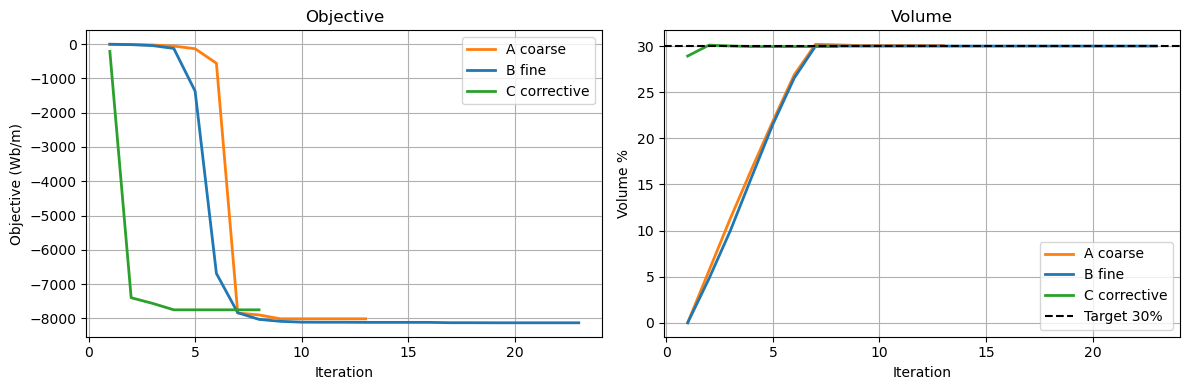

Run                         Flux (Wb/m)    Vol%  Iters
------------------------------------------------------
[A] Coarse                  8.01009e+03   30.06     13
[B] Fine                    8.12619e+03   30.00     23
[C] Corrective              7.74796e+03   29.95      8


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for hist, label, col in [(hist_c, "A coarse", "tab:orange"),
                         (hist_f, "B fine",   "tab:blue"),
                         (hist_cc,"C corrective","tab:green")]:
    iters = range(1, len(hist)+1)
    axes[0].plot(iters, [h[0] for h in hist], color=col, lw=2, label=label)
    axes[1].plot(iters, [h[1]*100 for h in hist], color=col, lw=2, label=label)
axes[1].axhline(V_TARGET*100, color='k', ls='--', label=f'Target {V_TARGET*100:.0f}%')
for ax in axes: ax.grid(True); ax.legend()
axes[0].set(xlabel="Iteration", ylabel="Objective (Wb/m)", title="Objective")
axes[1].set(xlabel="Iteration", ylabel="Volume %", title="Volume")
plt.tight_layout(); plt.show()

print(f"{'Run':<22} {'Flux (Wb/m)':>16}  {'Vol%':>6}  {'Iters':>5}")
print("-"*54)
for label, u, rho, mesh, hist in [
    ("[A] Coarse",     u_final_c,  rho_c,  mesh_coarse, hist_c),
    ("[B] Fine",       u_final_f,  rho_f,  mesh_fine,   hist_f),
    ("[C] Corrective", u_final_cc, rho_cc, mesh_coarse, hist_cc)]:
    vol = Integrate(rho*dx('Omega_c'),mesh) / Integrate(1,mesh,definedon=mesh.Materials('Omega_c'))
    print(f"{label:<22} {flux(u):>16.5e}  {vol*100:>6.2f}  {len(hist):>5}")


## Section E — BiGRU-corrected TOBS


1. Generate 20 designs via LHS
2. Evaluate coarse + fine FEA on each → collect `Δs = s_fine − s_coarse`
3. Train Bidirectional GRU on spatial element sequences to predict `Δs`
4. Run TOBS on coarse mesh using corrected sensitivity `s_coarse + GRU(Δs)`

**RNN choice — spatial BiGRU:** Elements fed in raster scan order (NW→SE).
Hidden state carries flux-path context in both directions.
Architecture: `5 → BiGRU(hidden=32, layers=2, bidir) → 16 → 1`


In [6]:
# ── E-1: LHS DoE — 20 binary designs ────────────────────────────────────────
from scipy.stats.qmc import LatinHypercube

N_DOE = 20
lhs   = LatinHypercube(d=N_c, seed=42).random(n=N_DOE)

def to_binary(row, eVol, V):
    x, cum = np.zeros(len(row)), 0.0
    for i in np.argsort(row)[::-1]:
        if cum + eVol[i] <= V + 1e-9: x[i]=1.0; cum+=eVol[i]
    return x

doe_x = np.array([to_binary(lhs[d], eVol_c, V_TARGET) for d in range(N_DOE)])
vols  = doe_x @ eVol_c
print(f"DoE: {N_DOE} designs  vol range {vols.min()*100:.1f}–{vols.max()*100:.1f}%")


DoE: 20 designs  vol range 29.9–30.0%


In [7]:
# ── E-2: Dual FEA — collect s_coarse, s_fine, |B| ───────────────────────────
_, f2c = KDTree(element_centroids(mesh_coarse)).query(element_centroids(mesh_fine))

rho_dc = GridFunction(L2(mesh_coarse, definedon='Omega_c'))
rho_df = GridFunction(L2(mesh_fine,   definedon='Omega_c'))

doe_sc = np.zeros((N_DOE, N_c))
doe_sf = np.zeros((N_DOE, N_c))
doe_B  = np.zeros((N_DOE, N_c))

for d in range(N_DOE):
    # coarse FEA
    rho_dc.vec.data.FV().NumPy()[mask_c] = doe_x[d]
    obj_c, sa_c, u_c = compute_sensitivity(rho_dc, mesh_coarse)
    doe_sc[d] = sa_c[mask_c]
    doe_B[d]  = element_flux_density(u_c, mesh_coarse)[mask_c]

    # fine FEA — project binary design via nearest centroid
    rho_df.vec.data.FV().NumPy()[mask_f] = doe_x[d][f2c]
    _, sa_f, _ = compute_sensitivity(rho_df, mesh_fine)
    sf = sa_f[mask_f]

    # group-mean: average fine sensitivities back to coarse elements
    num = np.zeros(N_c); cnt = np.zeros(N_c)
    for jj in range(N_f):
        ci = f2c[jj]
        if 0 <= ci < N_c: num[ci] += sf[jj]; cnt[ci] += 1
    doe_sf[d] = np.where(cnt > 0, num/cnt, doe_sc[d])
    print(f"  design {d+1:2d} done", end="\r")

ds_doe = doe_sf - doe_sc
print(f"\nDual FEA done.  Mean |Δs|={np.abs(ds_doe).mean():.3e}")


  design 20 done
Dual FEA done.  Mean |Δs|=1.275e-03


Trained 443 epochs  R²=0.9672  params=27361


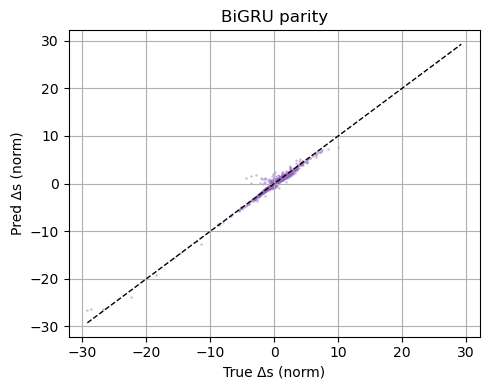

In [8]:
# ── E-3: BiGRU — define, train ───────────────────────────────────────────────
try:
    import torch, torch.nn as nn
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch",
        "--index-url", "https://download.pytorch.org/whl/cpu", "-q"])
    import torch, torch.nn as nn

# Raster-scan spatial ordering (NW → SE)
cents  = element_centroids(mesh_coarse)
cx     = (cents[:,0] - cents[:,0].min()) / (cents[:,0].ptp() + 1e-12)
cy     = (cents[:,1] - cents[:,1].min()) / (cents[:,1].ptp() + 1e-12)
order  = np.lexsort((cx, (cy * 10).astype(int)))
inv    = np.argsort(order)

# Normalisation statistics
fm = np.array([0.5, doe_sc.mean(), doe_B.mean(), 0.5, 0.5])
fs = np.array([0.5, doe_sc.std()+1e-12, doe_B.std()+1e-12, 0.3, 0.3])
tm, ts = ds_doe.mean(), ds_doe.std() + 1e-12

def make_X(x_d, sc_d, B_d):
    feat = np.column_stack([x_d, sc_d, B_d, cx, cy])
    return torch.tensor(((feat - fm) / fs).astype(np.float32)[order])

X = torch.stack([make_X(doe_x[d], doe_sc[d], doe_B[d]) for d in range(N_DOE)])
Y = torch.tensor(((ds_doe - tm) / ts).astype(np.float32)[:, order])

class BiGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru  = nn.GRU(5, 32, num_layers=2, batch_first=True,
                           bidirectional=True, dropout=0.2)
        self.head = nn.Sequential(nn.Linear(64, 16), nn.ReLU(), nn.Linear(16, 1))
    def forward(self, x):
        return self.head(self.gru(x)[0]).squeeze(-1)

torch.manual_seed(42)
model   = BiGRU()
opt     = torch.optim.Adam(model.parameters(), lr=3e-3)
sched   = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)
loss_fn = nn.MSELoss()
best, best_state, stall = 1e9, None, 0

for ep in range(800):
    model.train(); opt.zero_grad()
    loss = loss_fn(model(X), Y)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()
    v = loss.item(); sched.step(v)
    if v < best - 1e-6:
        best = v
        best_state = {k: p.clone() for k, p in model.state_dict().items()}
        stall = 0
    else:
        stall += 1
    if stall >= 60: break

model.load_state_dict(best_state); model.eval()
with torch.no_grad():
    yp = model(X).numpy(); yt = Y.numpy()
r2 = 1 - ((yt - yp)**2).sum() / ((yt - yt.mean())**2).sum()
print(f"Trained {ep+1} epochs  R²={r2:.4f}  "
      f"params={sum(p.numel() for p in model.parameters())}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(yt.flatten(), yp.flatten(), s=1, alpha=0.3, color='tab:purple')
lim = max(abs(yt).max(), abs(yp).max())
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1)
ax.set(xlabel='True Δs (norm)', ylabel='Pred Δs (norm)', title='BiGRU parity')
ax.grid(True); plt.tight_layout(); plt.show()


In [9]:
# ── E-4: Correction helper ───────────────────────────────────────────────────
def gru_correct(x, s_raw, B):
    feat  = np.column_stack([x, s_raw, B, cx, cy])
    x_in  = torch.tensor(((feat - fm) / fs).astype(np.float32)[order]).unsqueeze(0)
    with torch.no_grad():
        ds_norm = model(x_in).numpy().squeeze(0)
    ds = ds_norm[inv] * ts + tm          # denormalise + restore element order
    return s_raw + ds, ds


In [10]:
# ── E-5: BiGRU-corrected TOBS ────────────────────────────────────────────────
mask_e, eVol_e, N_e, rho_e = build_mesh_data(mesh_coarse)
x_e     = np.zeros(N_e)
delta_e = max(1, int(0.05 * N_e))
rho_e.vec.data.FV().NumPy()[mask_e] = x_e
scene_e = Draw(rho_e, mesh_coarse, min=0, max=1)

hist_e, s_prev_e, stall_e = [], None, 0
print(f"{'k':>4} {'obj':>12} {'vol%':>7} {'sw':>5} {'|Δs|':>10}")

for k in range(1, 101):
    obj, sa, u_e = compute_sensitivity(rho_e, mesh_coarse)
    s_raw = sa[mask_e]
    B_e   = element_flux_density(u_e, mesh_coarse)[mask_e]
    s_cor, ds  = gru_correct(x_e, s_raw, B_e)
    s_avg      = 0.5*(s_cor + s_prev_e) if s_prev_e is not None else s_cor.copy()
    s_prev_e   = s_cor.copy()
    x_new = tobs_update(x_e, s_avg, eVol_e, V_TARGET, delta_e)
    nsw   = int((x_new != x_e).sum())
    hist_e.append((obj, float(x_e @ eVol_e), nsw, float(np.abs(ds).mean())))
    x_e = x_new.copy()
    rho_e.vec.data.FV().NumPy()[mask_e] = x_e
    scene_e.Redraw()
    print(f"{k:4d} {obj:12.4e} {x_e@eVol_e*100:7.2f} {nsw:5d} {np.abs(ds).mean():10.3e}")
    stall_e = stall_e + 1 if nsw == 0 else 0
    if stall_e >= 5: break

u_final_e, _ = state(rho_e, mesh_coarse)
print(f"\n[E] flux={flux(u_final_e):.4e} Wb/m  vol={x_e@eVol_e*100:.2f}%  iters={k}")


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

   k          obj    vol%    sw       |Δs|
   1  -4.9722e+00    5.41    25  4.020e-04
   2  -8.9925e+00   10.59    25  1.089e-03
   3  -1.5750e+01   15.16    25  2.115e-03
   4  -2.6488e+01   19.61    25  3.558e-03
   5  -4.3549e+01   23.53    25  5.118e-03
   6  -9.1766e+01   28.72    25  6.991e-03
   7  -2.0264e+02   30.22    25  9.012e-03
   8  -4.0393e+02   29.81    25  7.720e-03
   9  -6.4612e+03   29.96    25  7.271e-03
  10  -6.5053e+03   30.06    11  7.601e-03
  11  -7.2508e+03   30.08     4  7.886e-03
  12  -7.2466e+03   30.03     5  7.855e-03
  13  -7.2530e+03   30.06     3  7.598e-03
  14  -7.2508e+03   30.08     4  7.886e-03
  15  -7.2466e+03   30.03     5  7.855e-03
  16  -7.2530e+03   30.06     3  7.598e-03
  17  -7.2508e+03   30.08     4  7.886e-03
  18  -7.2466e+03   30.03     5  7.855e-03
  19  -7.2530e+03   30.06     3  7.598e-03
  20  -7.2508e+03   30.08     4  7.886e-03
  21  -7.2466e+03   30.03     5  7.855e-03
  22  -7.2530e+03   30.06     3  7.598e-03
  23  -7.25

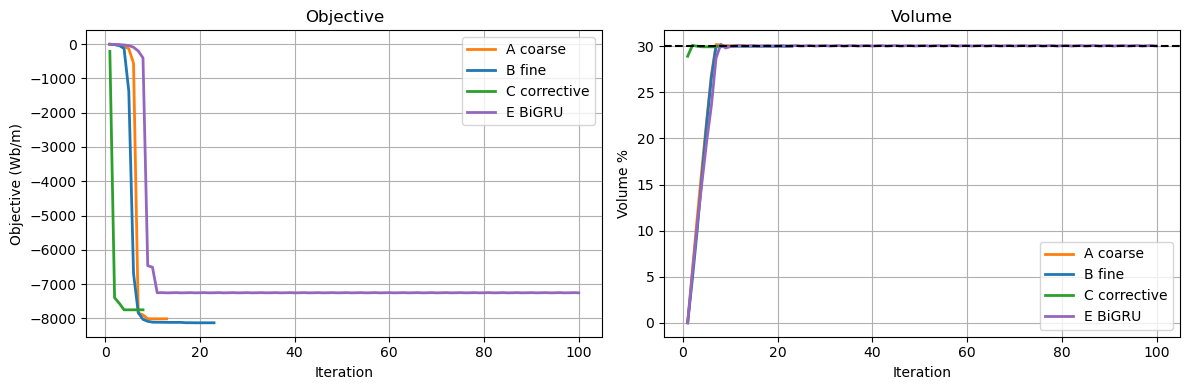

Run                         Flux (Wb/m)    Vol%  Iters
------------------------------------------------------
[A] Coarse                  8.01009e+03   30.06     13
[B] Fine                    8.12619e+03   30.00     23
[C] Corrective              7.74796e+03   29.95      8
[E] BiGRU                   7.25079e+03   30.06    100

BiGRU: R²=0.9672  params=27361


In [11]:
# ── E-6: Final comparison — A vs B vs C vs E ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
runs = [(hist_c, "A coarse",    "tab:orange"),
        (hist_f, "B fine",      "tab:blue"),
        (hist_cc,"C corrective","tab:green"),
        (hist_e, "E BiGRU",     "tab:purple")]
for hist, label, col in runs:
    iters = range(1, len(hist)+1)
    axes[0].plot(iters, [h[0] for h in hist], color=col, lw=2, label=label)
    axes[1].plot(iters, [h[1]*100 for h in hist], color=col, lw=2, label=label)
axes[1].axhline(V_TARGET*100, color='k', ls='--')
for ax in axes: ax.grid(True); ax.legend()
axes[0].set(xlabel="Iteration", ylabel="Objective (Wb/m)", title="Objective")
axes[1].set(xlabel="Iteration", ylabel="Volume %", title="Volume")
plt.tight_layout(); plt.show()

print(f"{'Run':<22} {'Flux (Wb/m)':>16}  {'Vol%':>6}  {'Iters':>5}")
print("-"*54)
for label, u, rho, mesh, hist in [
    ("[A] Coarse",     u_final_c,  rho_c,  mesh_coarse, hist_c),
    ("[B] Fine",       u_final_f,  rho_f,  mesh_fine,   hist_f),
    ("[C] Corrective", u_final_cc, rho_cc, mesh_coarse, hist_cc),
    ("[E] BiGRU",      u_final_e,  rho_e,  mesh_coarse, hist_e)]:
    vol = Integrate(rho*dx('Omega_c'),mesh)/Integrate(1,mesh,definedon=mesh.Materials('Omega_c'))
    print(f"{label:<22} {flux(u):>16.5e}  {vol*100:>6.2f}  {len(hist):>5}")
print(f"\nBiGRU: R²={r2:.4f}  params={sum(p.numel() for p in model.parameters())}")
